In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))  # go up to project root
from pydantic import BaseModel
from typing import Literal
from user_profile.schema import SearchParams, State, UserProfile, VideoInfo, TranscriptAnalysis, ScoreAnalysis
from prompts import orchestrator_prompt, score_prompt, search_prompt, transcript_prompt, profile_prompt
import os
from langchain_deepseek import ChatDeepSeek
from IPython.display import Image, display
from tools import rapidapi_youtube, youtube_transcript
import unicodedata
import importlib
from tqdm import tqdm
from trustcall import create_extractor
import uuid

In [2]:
from langgraph.graph import StateGraph, MessagesState, END, START
from langchain_core.runnables import RunnableConfig
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, merge_message_runs
from langgraph.checkpoint.memory import MemorySaver

In [3]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "language-learning-agent"

In [4]:
class ExecuteIntent(BaseModel):
    """Call this to execute the user's intent"""
    intent: Literal[
        "full_search",
        "transcript_only", 
        "rerank_only",
        "profile_update",
        "out_of_scope"
    ]
    search_params: SearchParams | None = None
    video_id: str | None = None

In [5]:
model = ChatDeepSeek(
    model = "deepseek-chat",
    temperature=0.5
)

In [6]:
def get_user_profile(user_id: str, store : BaseStore) -> UserProfile:
    # In a real application, this would fetch the user profile from a database
    # For this example, we'll just return a dummy profile
    namespace = ("profile", user_id)
    memories = store.search(namespace)
    if memories:
        user_profile = memories[0].value
    else:
        user_profile = None
    return user_profile

In [100]:
def orchestrator(state : State, config : RunnableConfig, store : BaseStore):
    
    for msg in state["messages"]:
        print(f"{msg.type}: {str(msg.content)[:50]}")
        print("---")

    # # Retrieve the user state from the store
    user_id = config["configurable"]["user_id"]
    user_profile = get_user_profile(user_id, store)

    system_msg = orchestrator_prompt.PROMPT.format(user_profile=user_profile)

    response = model.bind_tools([ExecuteIntent]).invoke([SystemMessage(content=system_msg)] + state["messages"])
    
    if response.tool_calls:
        print("Orchestrator made tool call!")
        args = response.tool_calls[0]["args"]  # reading what LLM generated
        print(f"tool call args: {args}")
        search_params = args.get("search_params", None)  # getting the specific field
        if search_params and len(search_params["language"]) > 2:
            return {
                "messages": [HumanMessage(content="Please use a language code (e.g. 'de', 'fr') not the full language name")],
                "search_params": None,
                "video_id": None
            }
        video_id = args.get("video_id", None)
    else:
        search_params = None
        video_id = None

    return {"messages" : [response], "search_params": search_params, "video_id" : video_id}

Testing the Orchestrator

In [ ]:
from unittest.mock import MagicMock
config = {"configurable": {"user_id": "test_user"}}
    
store = MagicMock()
store.search.return_value = []  # empty profile

# Mock state with a user message 
state = {
    "messages": [HumanMessage(content="Find me German cooking videos at B1")],
    "search_params": None,
    "videos": None,
    "user_profile": None
}

result = orchestrator(state, config, store)
print(result["search_params"])

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 1037, 'total_tokens': 1118, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1024}, 'prompt_cache_hit_tokens': 1024, 'prompt_cache_miss_tokens': 13}, 'model_provider': 'deepseek', 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_eaab8d114b_prod0820_fp8_kvcache', 'id': '290cd629-7f16-4305-9df1-46a65e4c55bf', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cda8d-0f81-7f33-aacf-521cf75b6136-0', tool_calls=[{'name': 'ExecuteIntent', 'args': {'intent': 'full_search', 'search_params': {'topic': 'cooking', 'language': 'German', 'target_level': 'B1', 'max_results': 10}}, 'id': 'call_00_OjDtdB85oRskiCSTtsUL70F2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1037, 'output_tokens': 81, 'total_tokens': 1118, 'input_token_details': {'cache_read

In [55]:
result["search_params"]

{'topic': 'cooking',
 'language': 'German',
 'target_level': 'B1',
 'max_results': 10}

In [49]:
mock_videos = [
    VideoInfo(
        video_id="3gmJXVqwiHQ",
        title=" 8 films pour améliorer ton français ",
        channel_id="UCcinema123",  # highly rated saved channel
        channel_title="Cinéma Facile",
        CC=True,
        published_time="1 month ago",
        views=85000,
        detected_language="French",
        detected_level="A2",      # perfect level match
        for_students=True,
        score=None
        # expected score: HIGHEST — cinema interest, saved channel,
        # perfect level, for students, CC available
    ),
    VideoInfo(
        video_id="Au7DPVUpc6A",
        title="La Révolution Française de 1789 à 1792 ",
        channel_id="UChistoire456",  # saved channel
        channel_title="Histoire Vivante",
        CC=True,
        published_time="3 months ago",
        views=120000,
        detected_language="French",
        detected_level="B1",      # slightly above target A2
        for_students=False,
        score=None
        # expected score: HIGH — history interest, saved channel
        # slight penalty for being above target level
    ),
    VideoInfo(
        video_id="Xu-FLmk7t5Y",
        title=" LA CUISINE FRANCAISE : C'EST SACRÉ ! ",
        channel_id="UCfood999",
        channel_title="Cuisine Française",
        CC=True,
        published_time="2 weeks ago",
        views=67000,
        detected_language="French",
        detected_level="A2",      # perfect level match
        for_students=False,
        score=None
        # expected score: MEDIUM-HIGH — gastronomy interest, right level
        # unknown channel, no ratings
    ),
    VideoInfo(
        video_id="dp4I9DIK_pk",
        title="Présidentielle 2022 : le débat entre Macron et Le Pen résumé en 6 minutes",
        channel_id="UCnews777",
        channel_title="France Info",
        CC=False,
        published_time="1 week ago",
        views=450000,
        detected_language="French",
        detected_level="C1",      # way above target
        for_students=False,
        score=None
        # expected score: LOW — not in interests, way above level,
        # no CC, not for students
    ),
    VideoInfo(
        video_id="2e7DAdOyb10",
        title="BAGARRES et INSULTES 😤 Les meilleurs moments ! | LES ANGES | COMPILATION",
        channel_id="UCreality789",  # poorly rated channel
        channel_title="Reality France",
        CC=False,
        published_time="2 days ago",
        views=1500000,
        detected_language="French",
        detected_level="B2",      # above target
        for_students=False,
        score=None
        # expected score: LOWEST — reality TV (disliked), poorly rated channel,
        # above level, no CC
    ),
]

In [80]:
mock_transcripts = {
    "3gmJXVqwiHQ": "Bonjour à tous ! Aujourd'hui je vous présente huit films pour améliorer votre français. Ces films sont parfaits pour les débutants. Les dialogues sont simples et clairs. Vous pouvez activer les sous-titres en français. Regarder des films est une excellente méthode pour apprendre une nouvelle langue naturellement.",
    
    "Au7DPVUpc6A": "La Révolution Française commence en 1789 avec la prise de la Bastille. Le peuple français était mécontent du roi Louis XVI. Les inégalités sociales étaient très importantes. Les idées des philosophes des Lumières ont influencé les révolutionnaires. Cette période a complètement transformé la société française et européenne.",
    
    "Xu-FLmk7t5Y": "La cuisine française est reconnue dans le monde entier comme un patrimoine culturel important. Aujourd'hui nous préparons un bœuf bourguignon traditionnel. Il faut du vin rouge, des carottes, des oignons et de la viande. La recette est simple mais demande beaucoup de patience et d'amour pour la gastronomie.",
    
    "dp4I9DIK_pk": "Ce débat présidentiel entre Emmanuel Macron et Marine Le Pen a été particulièrement tendu. Les deux candidats s'affrontent sur des questions économiques complexes, notamment concernant le pouvoir d'achat, la politique énergétique et les relations internationales. Les arguments échangés reflètent des visions diamétralement opposées de la société française contemporaine.",
    
    "2e7DAdOyb10": "Ouais nan mais là franchement il m'a cherché hein ! T'as vu comment il m'a regardé ? J'suis pas du genre à me laisser faire moi. Vas-y on s'explique dehors si t'as quelque chose à dire ! Les autres candidats de la villa essaient de calmer la situation mais ça dégénère rapidement."
}

In [50]:
def search_agent(state : State, config : RunnableConfig, store : BaseStore):
    # This agent is responsible for searching videos based on the user's preferences and the search parameters generated by the orchestrator.
    # # Get user profile
    user_id = config["configurable"]["user_id"]
    user_profile = get_user_profile(user_id, store)
    
    # Get the search parameters from state
    search_params = state["search_params"]
    system_msg = search_prompt.PROMPT.format(search_params=search_params, user_profile=user_profile)

    # Use the LLM to generate a query
    response = model.invoke([SystemMessage(content=system_msg)])
    query = (response.content).split("\n")[0]
    
    # Keep only ASCII characters
    normalized = unicodedata.normalize("NFD", query)
    query = "".join(c for c in normalized if unicodedata.category(c) != "Mn")

    print("Generated query:", query)
    print("Language code:", search_params["language"])
    print("Max results:", search_params["max_results"])

    # Call the search tool with the generated query
    # search_results = rapidapi_youtube.search_youtube(
    #     query=query,
    #     language=[search_params["language"], "en"],
    #     max_results=search_params["max_results"]
    # )
    search_results = mock_videos

    # Filter the search results to only include one video per channel
    seen_channels = set()
    videos = []
    for video in search_results:
        if video.channel_title not in seen_channels:
            seen_channels.add(video.channel_title)
            videos.append(video)

    # This agent only updates the videos field in the state.
    return {"videos": videos}

Testing the Search Agent

In [ ]:
importlib.reload(search_prompt)
importlib.reload(rapidapi_youtube)

<module 'tools.rapidapi_youtube' from '/home/renan-florencio/Documents/language-learning-agent/tools/rapidapi_youtube.py'>

In [9]:
from unittest.mock import MagicMock
config = {"configurable": {"user_id": "test_user"}}
    
store = MagicMock()
store.search.return_value = []  # empty profile

# Mock state with a user message 
state = {
    "messages": [HumanMessage(content="Find me French cooking videos at B1")],
    "search_params": {
        'topic': 'cooking',
        'language': 'fr',
        'target_level': 'B1',
        'max_results': 10
        },
    "videos": None,
    "user_profile": None
}

result = search_agent(state, config, store)
print(result["videos"])

Generated query: cuisine recettes francaises faciles
Language code: fr
Max results: 10
[VideoInfo(video_id='G_jN7icWjk4', title='POULET CHASSEUR | Une recette française, facile et incroyablement savoureuse', channel_id='UCSLyEx8ISkp567AjOAHYN5Q', channel_title='Chef Michel Dumas', CC=False, published_time='il y a 1 an', views=207381, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='B4mJnpWHrNI', title='UNE BLANQUETTE DE VEAU FACILE ET SAVOUREUSE (Recette Française)', channel_id='UC6XhUxvJadB4O4CJxcI8JyQ', channel_title='TradiCuisine by Ocena Milly (Tradicuisine)', CC=False, published_time='il y a 3 ans', views=189593, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='IAVE4mfeDTA', title='Poulet Gaston Gérard - Les recettes de François-Régis Gaudry', channel_id='UCJldRgT_D7Am-ErRHQZ90uw', channel_title='France Inter', CC=False, published_time='il y a 2 ans', views=150670, detected_language=Non

In [8]:
importlib.reload(youtube_transcript)

<module 'tools.youtube_transcript' from '/home/renan-florencio/Documents/language-learning-agent/tools/youtube_transcript.py'>

In [79]:
def transcript_agent(state : State, config : RunnableConfig, store : BaseStore):
    # This agent is responsible for generating transcripts for videos that are found to be relevant to the user's preferences.
    if not state["videos"]:
        return {"transcripts": None}
    
    language = state["search_params"]["language"]
    videos = state["videos"]

    for v in tqdm(videos, desc="Extracting information from transcripts", unit="video"):
        
        # try:
        #     transcript, _ = youtube_transcript.get_transcript(v.video_id, [language])
        # except Exception as e:
        #     print(f"Could not fetch transcript for video {v.video_id}... Error: {e}")
        #     transcript, _ = None, None
        transcript = mock_transcripts.get(v.video_id, None)

        detected_information = model.with_structured_output(TranscriptAnalysis).invoke(
            [SystemMessage(content=transcript_prompt.PROMPT.format(transcript=transcript))]
        )
        v.level_explanation = detected_information.level_explanation
        v.detected_language = detected_information.detected_language
        v.detected_level = detected_information.detected_level
        v.for_students = detected_information.for_students

    return {"videos": videos}

In [14]:
videos_teste = [VideoInfo(video_id='G_jN7icWjk4', title='POULET CHASSEUR | Une recette française, facile et incroyablement savoureuse', channel_id='UCSLyEx8ISkp567AjOAHYN5Q', channel_title='Chef Michel Dumas', CC=False, published_time='il y a 1 an', views=207381, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='B4mJnpWHrNI', title='UNE BLANQUETTE DE VEAU FACILE ET SAVOUREUSE (Recette Française)', channel_id='UC6XhUxvJadB4O4CJxcI8JyQ', channel_title='TradiCuisine by Ocena Milly (Tradicuisine)', CC=False, published_time='il y a 3 ans', views=189593, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='IAVE4mfeDTA', title='Poulet Gaston Gérard - Les recettes de François-Régis Gaudry', channel_id='UCJldRgT_D7Am-ErRHQZ90uw', channel_title='France Inter', CC=False, published_time='il y a 2 ans', views=150670, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='hBT_fFTjmck', title="Recette Simple et Rapide de Filet de poulet  au Four ,que Vous n'avez pas encore Cuisinée !", channel_id='UCyfyGuxNX-PMFF5gcpaM2mQ', channel_title='Cuisine Simple', CC=False, published_time='il y a 5 ans', views=7592137, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='kM1ff5bJAhE', title='Petits Pois A La Viande et Aux Pommes de Terre', channel_id='UC-izX-l01iPFN3ycEiaKe3A', channel_title="Noelia's Cooking", CC=False, published_time='il y a 1 an', views=760692, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='2Ez41jl5d_0', title='Cette salade de pommes de terre ne quittera plus vos tables 😍 STYLE PIEMONTAISE 🥔', channel_id='UCti7qANQHf_h2chQq72vV_w', channel_title='Deli Cuisine', CC=False, published_time='il y a 2 ans', views=756682, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='4JZRbKZDLxs', title='Facile à préparer et très savoureux - poulet à la française très appétissant!| Savoureux.tv', channel_id='UCjEgEoelbEkqQyJgT-szXEQ', channel_title='Savoureux.tv', CC=False, published_time='il y a 5 ans', views=169093, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='aIEGtMHrC0M', title='🥣 La sauce au poivre', channel_id='UCO5U-JvGcz9B6ZoWvW77Tng', channel_title='Philippe Etchebest', CC=False, published_time='il y a 2 ans', views=1034136, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='GLweUjv94d8', title='Verser simplement la viande hachée sur les pommes de terre‼️Délicieux et facile  #138', channel_id='UCWp0LYORUpfcaGZspjO8GKg', channel_title='Dans La Cuisine de Sou', CC=False, published_time='il y a 4 ans', views=25803288, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='kO_tfA9jVQw', title='Bœuf Bourguignon Traditionnel - Recette Facile et Savoureuse !', channel_id='UCePeGAC1b668JFElLSsIrYA', channel_title='A table Juju', CC=False, published_time='il y a 1 an', views=221982, detected_language=None, detected_level=None, for_students=None, score=None)]

In [17]:
print(videos_teste)

[VideoInfo(video_id='G_jN7icWjk4', title='POULET CHASSEUR | Une recette française, facile et incroyablement savoureuse', channel_id='UCSLyEx8ISkp567AjOAHYN5Q', channel_title='Chef Michel Dumas', CC=False, published_time='il y a 1 an', views=207381, detected_language=None, detected_level=None, for_students=None, score=None), VideoInfo(video_id='B4mJnpWHrNI', title='UNE BLANQUETTE DE VEAU FACILE ET SAVOUREUSE (Recette Française)', channel_id='UC6XhUxvJadB4O4CJxcI8JyQ', channel_title='TradiCuisine by Ocena Milly (Tradicuisine)', CC=False, published_time='il y a 3 ans', views=189593, detected_language=None, detected_level=None, for_students=None, score=None)]


In [ ]:
# Mock state with a user message 
state = {
    "messages": [HumanMessage(content="Find me French cooking videos at B1")],
    "search_params": {
        'topic': 'cooking',
        'language': 'fr',
        'target_level': 'B1',
        'max_results': 10
        },
    "videos": [VideoInfo(video_id='G_jN7icWjk4', title='POULET CHASSEUR | Une recette française, facile et incroyablement savoureuse', channel_id='UCSLyEx8ISkp567AjOAHYN5Q', channel_title='Chef Michel Dumas', CC=False, published_time='il y a 1 an', views=207381, detected_language=None, detected_level=None, for_students=None, score=None)],
    "user_profile": None
}

result = transcript_agent(state, config, store)
print(result["videos"])

[VideoInfo(video_id='G_jN7icWjk4', title='POULET CHASSEUR | Une recette française, facile et incroyablement savoureuse', channel_id='UCSLyEx8ISkp567AjOAHYN5Q', channel_title='Chef Michel Dumas', CC=False, published_time='il y a 1 an', views=207381, detected_language='French', detected_level='B1', level_explanation='The transcript is entirely in French, as evidenced by phrases like "salut mes amis bienvenue à la maison", "poulet chasseurs", "champignons", and other cooking-related vocabulary. The content appears to be a cooking tutorial or demonstration showing how to prepare a chicken dish with mushrooms and herbs. The language is conversational and instructional, with the speaker guiding the viewer through the cooking process. The vocabulary is specific to cooking and food preparation, with some technical terms but generally accessible language. There\'s no evidence of language teaching elements like vocabulary explanations, grammar instruction, or simplified language for learners. Th

In [88]:
def scoring_agent(state: State, config: RunnableConfig, store: BaseStore) -> dict:
    user_id = config['configurable']['user_id']
    user_profile = get_user_profile(user_id, store)
    videos = state['videos']
    
    if videos is None:
        print("No videos found for scoring.")
        return {"videos": []}
    
    for video in tqdm(videos, desc="Scoring videos", unit="video"):
        system_msg = score_prompt.PROMPT.format(
            user_profile=user_profile,
            video_info=video,
            search_params=state["search_params"],
        )
        model_score = model.with_structured_output(ScoreAnalysis).invoke(
            [SystemMessage(content=system_msg)]
        )
        print(f"Video ID: {video.video_id} - Score: {model_score.score} - Explanation: {model_score.score_explanation}")
        video.score_explanation = model_score.score_explanation
        video.score = model_score.score
    
    videos.sort(key=lambda x: x.score or 0, reverse=True)
    return {"videos": videos}

In [48]:
from unittest.mock import MagicMock
from langchain_core.messages import HumanMessage
from user_profile.schema import UserProfile, VideoInfo, SearchParams

# Plausible user profile — French learner
mock_profile_fr = UserProfile(
    interests=["cinema", "history", "gastronomy"],
    dislikes=["reality TV", "sports"],
    languages=["English", "French"],
    language_levels={"English": "C2", "French": "A2"},
    saved_channels_id=["UCcinema123", "UChistoire456"],
    channel_ratings={
        "UCcinema123": 5.0,   # highly rated French cinema channel
        "UCreality789": 1.0   # poorly rated reality TV channel
    },
    video_ratings={
        "vid_easy_french": 5.0,   # loved easy French content
        "vid_hard_debate": 1.0    # hated complex French political debate
    }
)

# Mock store
mock_memory_fr = MagicMock()
mock_memory_fr.value = mock_profile_fr.model_dump()
store_fr = MagicMock()
store_fr.search.return_value = [mock_memory_fr]

# Videos with different expected scores
mock_videos_fr = [
    VideoInfo(
        video_id="3gmJXVqwiHQ",
        title=" 8 films pour améliorer ton français ",
        channel_id="UCcinema123",  # highly rated saved channel
        channel_title="Cinéma Facile",
        CC=True,
        published_time="1 month ago",
        views=85000,
        detected_language="French",
        detected_level="A2",      # perfect level match
        for_students=True,
        score=None
        # expected score: HIGHEST — cinema interest, saved channel,
        # perfect level, for students, CC available
    ),
    VideoInfo(
        video_id="Au7DPVUpc6A",
        title="La Révolution Française de 1789 à 1792 ",
        channel_id="UChistoire456",  # saved channel
        channel_title="Histoire Vivante",
        CC=True,
        published_time="3 months ago",
        views=120000,
        detected_language="French",
        detected_level="B1",      # slightly above target A2
        for_students=False,
        score=None
        # expected score: HIGH — history interest, saved channel
        # slight penalty for being above target level
    ),
    VideoInfo(
        video_id="Xu-FLmk7t5Y",
        title=" LA CUISINE FRANCAISE : C'EST SACRÉ ! ",
        channel_id="UCfood999",
        channel_title="Cuisine Française",
        CC=True,
        published_time="2 weeks ago",
        views=67000,
        detected_language="French",
        detected_level="A2",      # perfect level match
        for_students=False,
        score=None
        # expected score: MEDIUM-HIGH — gastronomy interest, right level
        # unknown channel, no ratings
    ),
    VideoInfo(
        video_id="dp4I9DIK_pk",
        title="Présidentielle 2022 : le débat entre Macron et Le Pen résumé en 6 minutes",
        channel_id="UCnews777",
        channel_title="France Info",
        CC=False,
        published_time="1 week ago",
        views=450000,
        detected_language="French",
        detected_level="C1",      # way above target
        for_students=False,
        score=None
        # expected score: LOW — not in interests, way above level,
        # no CC, not for students
    ),
    VideoInfo(
        video_id="2e7DAdOyb10",
        title="BAGARRES et INSULTES 😤 Les meilleurs moments ! | LES ANGES | COMPILATION",
        channel_id="UCreality789",  # poorly rated channel
        channel_title="Reality France",
        CC=False,
        published_time="2 days ago",
        views=1500000,
        detected_language="French",
        detected_level="B2",      # above target
        for_students=False,
        score=None
        # expected score: LOWEST — reality TV (disliked), poorly rated channel,
        # above level, no CC
    ),
]

config_fr = {"configurable": {"user_id": "test_user_fr"}}

state_fr = {
    "messages": [HumanMessage(content="Find me French cinema videos at A2")],
    "search_params": SearchParams(
        topic="cinema",
        language="fr",
        target_level="A2",
        max_results=10
    ),
    "videos": mock_videos_fr,
}

In [30]:
results = scoring_agent(state_fr, config_fr, store_fr)

Scoring videos: 100%|██████████| 5/5 [00:58<00:00, 11.79s/video]


In [31]:
for r in results["videos"]:
    print(f"Video title: {r.title}")
    print(f"Score: {r.score}")
    print(f"Score explanation: {r.score_explanation}")
    print("================")

Video title: Introduction au Cinéma Français pour Débutants
Score: 95
Score explanation: This video scores highly because it perfectly matches the user's search parameters and preferences. The topic is 'cinema' which is one of the user's interests, the language is French (target language 'fr'), and the detected level is A2 matching the user's target level. The channel (UCcinema123) is both saved in the user's profile and has a perfect 5.0 rating. The video is specifically for students (for_students=True), which is ideal since the user's target level is A2 (A1-B1 range). The video has good engagement (85,000 views) and is recent (1 month ago). The user's French level is A2, so this content is perfectly suited to their language ability. All factors align perfectly for high relevance.
Video title: Histoire de France: La Révolution Française
Score: 75
Score explanation: The video has several positive factors: 1) It matches the user's interest in history (one of their top interests), 2) It'

In [ ]:
def profile_update_agent(state : State, config : RunnableConfig, store : BaseStore):
    # This agent is responsible for updating the user's profile based on their interactions and feedback.
    user_id = config['configurable']['user_id']
    namespace = ("profile", user_id)
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "UserProfile"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )
    
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=profile_prompt.PROMPT)] + state["messages"][-3:-1]))
    # Create the Trustcall extractor for updating the user profile 
    profile_extractor = create_extractor(
        model,
        tools=[UserProfile],
        tool_choice=tool_name,
    )

    # This might return several updates if the message has several updates
    result = profile_extractor.invoke({"messages": updated_messages, 
                                         "existing": existing_memories}) 

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(
            namespace,                              # ("profile", user_id) — where to store
            rmeta.get("json_doc_id", str(uuid.uuid4())),  # key — reuses existing doc id if updating
            r.model_dump(mode="json"),             # value — the updated UserProfile as dict
        )
    tool_calls = state['messages'][-1].tool_calls
    return {"messages": [{"role": "tool", "content": "updated profile", "tool_call_id":tool_calls[0]['id']}]}

In [12]:
import uuid
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.store.memory import InMemoryStore
from user_profile.schema import UserProfile, SearchParams

# Real in-memory store
store = InMemoryStore()

# Put the mock profile into the store
user_id = "test_user"
namespace = ("profile", user_id)
mock_profile = UserProfile(
    interests=["cinema", "history", "gastronomy"],
    dislikes=["reality TV", "sports"],
    languages=["English", "French"],
    language_levels={"English": "C2", "French": "A2"},
    saved_channels_id=["UCcinema123", "UChistoire456"],
    channel_ratings={
        "UCcinema123": 5.0,
        "UCreality789": 1.0
    },
    video_ratings={
        "vid_easy_french": 5.0,
        "vid_hard_debate": 1.0
    }
)

# Store the profile with a fixed key
store.put(namespace, str(uuid.uuid4()), mock_profile.model_dump())

config = {"configurable": {"user_id": user_id}}

state = {
    "messages": [
        HumanMessage(content="I'm starting to learn Spanish"),
        AIMessage(content="", tool_calls=[{
            "name": "ExecuteIntent",
            "args": {"intent": "profile_update"},
            "id": "call_123",
            "type": "tool_call"
        }])
    ],
    "search_params": SearchParams(
        topic="cinema",
        language="fr",
        target_level="A2",
        max_results=10
    ),
    "videos": None,
}

In [60]:
results = profile_update_agent(state, config, store)

In [61]:
store.search(namespace)[0].value

{'interests': ['cinema', 'history', 'gastronomy'],
 'dislikes': ['reality TV', 'sports'],
 'languages': ['English', 'French', 'Spanish'],
 'language_levels': {'English': 'C2', 'French': 'A2', 'Spanish': 'A1'},
 'saved_channels_id': ['UCcinema123', 'UChistoire456'],
 'channel_ratings': {'UCcinema123': 5.0, 'UCreality789': 1.0},
 'video_ratings': {'vid_easy_french': 5.0, 'vid_hard_debate': 1.0}}

In [82]:
def full_search_pipeline(state : State, config : RunnableConfig, store : BaseStore):
    state["videos"] = search_agent(state, config, store)["videos"]
    state["videos"] = transcript_agent(state, config, store)["videos"]
    state["videos"] = scoring_agent(state, config, store)["videos"]

    video_summary = "\n".join([
        f"{i+1}. {v.title}\n"
        f"   Channel: {v.channel_title}\n"
        f"   Level: {v.detected_level} | Score: {v.score}/100\n"
        f"   Level Explanation: {v.level_explanation}\n"
        f"   Score Explanation: {v.score_explanation}\n"
        f"   For Students: {'Yes' if v.for_students else 'No'}\n"
        f"   URL: https://www.youtube.com/watch?v={v.video_id}"
        for i, v in enumerate(state["videos"])
    ])  

    tool_call_id = state["messages"][-1].tool_calls[0]["id"] # Get the id of the tool call
    return {
        "videos": state["videos"],
        "messages" : [{"role" : "tool", "content" : f"Found {len(state['videos'])} scored videos\n{video_summary}", "tool_call_id": tool_call_id}]
    }

In [83]:
def transcript_only_pipeline(state: State, config : RunnableConfig, store : BaseStore):
    if not state["video_id"]:
        raise ValueError("No video_id provided for transcript_only_pipeline")
    
    video_id = state["video_id"]
    # The transcript agent nesses a video to operate, just create a basic one
    state["videos"] = [VideoInfo(
        video_id=video_id,
        title="Unknown",
        channel_id="Unknown",
        channel_title="Unknown",
        CC=False,
        published_time="Unknown",
        views=0
    )]
    state["videos"] = transcript_agent(state, config, store)["videos"]
    tool_call_id = state["messages"][-1].tool_calls[0]["id"] # Get the id of the tool call
    return {
        "videos": state["videos"],
        "messages" : [{"role" : "tool", "content" : f"Detected level of {len(state['videos'])} videos.", "tool_call_id": tool_call_id}]
    }

In [84]:
def route_intent(state: State, config : RunnableConfig, store : BaseStore) -> Literal[END, "full_search_pipeline", "transcript_only_pipeline", "profile_update_agent"]:
    last_message = state["messages"][-1]

    if not last_message.tool_calls:
        return END

    intent = last_message.tool_calls[0]["args"]["intent"] 
    print(f"Intent: {intent}")

    if intent == "full_search":
        return "full_search_pipeline"
    elif intent == "transcript_only":
        return "transcript_only_pipeline"
    elif intent == "profile_update":
        return "profile_update_agent"
    else:
        return END

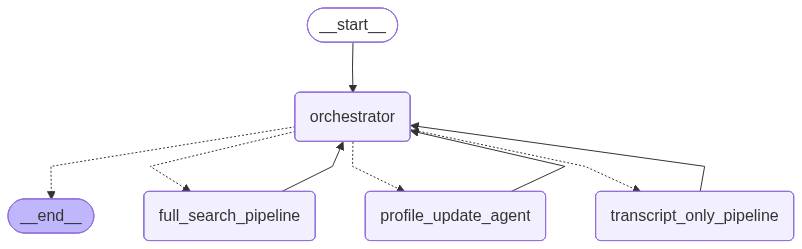

In [101]:
builder = StateGraph(State)
builder.add_node("orchestrator", orchestrator)
builder.add_node("full_search_pipeline", full_search_pipeline)
builder.add_node("transcript_only_pipeline", transcript_only_pipeline)
builder.add_node("profile_update_agent", profile_update_agent)

builder.add_edge(START, "orchestrator")
builder.add_conditional_edges("orchestrator", route_intent)
builder.add_edge("full_search_pipeline", "orchestrator")
builder.add_edge("transcript_only_pipeline", "orchestrator")
builder.add_edge("profile_update_agent", "orchestrator")

# Store long-term
across_thread_memory = InMemoryStore()

# Store short-term
in_thread_memory = MemorySaver()

graph = builder.compile(checkpointer=in_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [122]:
importlib.reload(orchestrator_prompt)

<module 'prompts.orchestrator_prompt' from '/home/renan-florencio/Documents/language-learning-agent/prompts/orchestrator_prompt.py'>

In [89]:
result = graph.stream(
    {"messages": [HumanMessage(content="Find me 5 French cooking videos at B1")]},
    config={
        "configurable": {
            "thread_id": f"{uuid.uuid4()}",
            "user_id": "test_user"
        }
    }
)

chunks = []
for chunk in result:
    chunks.append(chunk)
    print(chunk)

human: Find me 5 French cooking videos at B1
---
Orchestrator made tool call!
Intent: full_search
{'orchestrator': {'messages': [AIMessage(content="I'll help you find 5 French cooking videos at B1 level. Let me search for these videos for you.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 1504, 'total_tokens': 1615, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1472}, 'prompt_cache_hit_tokens': 1472, 'prompt_cache_miss_tokens': 32}, 'model_provider': 'deepseek', 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_eaab8d114b_prod0820_fp8_kvcache', 'id': '1a394885-c3fd-4b30-bd43-075e5a309f96', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cf309-b1fc-73e1-85b9-6b1e1a54e31b-0', tool_calls=[{'name': 'ExecuteIntent', 'args': {'intent': 'full_search', 'search_params': {'topic': 'cooking', 'language': 'fr', 'target_level': 'B1', 'max_results': 5}}

Scoring videos:  20%|██        | 1/5 [00:06<00:25,  6.44s/video]

Video ID: 3gmJXVqwiHQ - Score: 25 - Explanation: The video is completely mismatched to the user's requested topic of 'cooking'. While it matches the language (French), target level (B1), and has for_students=True (good for A1-B1 learners), the fundamental topic mismatch makes it largely irrelevant. The video is about learning French through films, which has no relation to cooking. The positive factors like recent upload (1 month ago), good engagement (85k views), and educational format cannot overcome the complete lack of alignment with the user's specific cooking interest. The user explicitly requested cooking content, and this video provides none of that.


Scoring videos:  40%|████      | 2/5 [00:14<00:21,  7.23s/video]

Video ID: Au7DPVUpc6A - Score: 15 - Explanation: The video is completely irrelevant to the user's search request. The user is looking for cooking content in French at B1 level, but this video is about the French Revolution (history topic) and is at B1 level according to the detected level. While the language matches (French) and the level matches (B1), the topic mismatch is fundamental - cooking vs. history. The video is not for students (for_students=False), which is important since the user's target level is B1 and should prioritize student-focused content. The video has good view count (120k) and is recent (3 months ago), but these positive factors cannot overcome the fundamental mismatch in topic. The user profile is empty, so no additional preferences can be considered.


...

Scoring videos:  80%|████████  | 4/5 [00:28<00:07,  7.36s/video]

Video ID: dp4I9DIK_pk - Score: 5 - Explanation: This video receives a very low score because it completely fails to match the user's request. The user is searching for cooking content in French at B1 level, but this video is about French presidential politics (Macron vs Le Pen debate). There is an absolute topic mismatch - cooking vs political debate. While the language is French which matches the user's language preference, the content level is C1 (advanced native level) while the user requested B1 (intermediate). The video is not for_students, which is important since the user requested B1 level. The user profile is empty, so there are no personal preferences to consider. The video has high views (450k) and is recent (1 week ago), but these positive factors cannot compensate for the complete topic mismatch and inappropriate level for the user's needs.


Scoring videos: 100%|██████████| 5/5 [00:36<00:00,  7.39s/video]

Video ID: 2e7DAdOyb10 - Score: 5 - Explanation: The video is completely irrelevant to the user's request for cooking content in French at B1 level. The video is about reality TV drama (BAGARRES et INSULTES) with native-level French (B2/C1) containing slang and informal language, which is too advanced for a B1 learner. The content is not educational (for_students=False) and doesn't match the cooking topic. While the language is French as requested, the level mismatch and topic irrelevance make this video unsuitable for the user's needs. The user is looking for cooking content specifically, and this video is about reality TV conflicts. The video has high views (1.5M) and is recent (2 days ago), but these positive factors don't compensate for the complete topic mismatch and inappropriate language level for a B1 learner.
{'full_search_pipeline': {'videos': [VideoInfo(video_id='Xu-FLmk7t5Y', title=" LA CUISINE FRANCAISE : C'EST SACRÉ ! ", channel_id='UCfood999', channel_title='Cuisine Franç

{'orchestrator': {'messages': [AIMessage(content="I found 5 French videos, but unfortunately only one of them is actually about cooking. Here are the results:\n\n**1. LA CUISINE FRANCAISE : C'EST SACRÉ !**\n- **Channel:** Cuisine Française\n- **Level:** B1 (Score: 55/100)\n- **For Students:** No\n- **Link:** https://www.youtube.com/watch?v=Xu-FLmk7t5Y\n- **Explanation:** This is a cooking video about traditional French cuisine and making beef bourguignon. It matches your requested topic (cooking) and language (French) at B1 level, but it's native content rather than student-focused material. The vocabulary includes culinary terms that could be challenging for B1 learners.\n\nThe other 4 videos were not about cooking - they covered topics like French films for language learning, French Revolution history, political debates, and reality TV drama. These were filtered out because they don't match your cooking interest.\n\nWould you like me to search for more French cooking videos at B1 lev

In [90]:
print(chunks[-1]['orchestrator']['messages'][0].content)

I found 5 French videos, but unfortunately only one of them is actually about cooking. Here are the results:

**1. LA CUISINE FRANCAISE : C'EST SACRÉ !**
- **Channel:** Cuisine Française
- **Level:** B1 (Score: 55/100)
- **For Students:** No
- **Link:** https://www.youtube.com/watch?v=Xu-FLmk7t5Y
- **Explanation:** This is a cooking video about traditional French cuisine and making beef bourguignon. It matches your requested topic (cooking) and language (French) at B1 level, but it's native content rather than student-focused material. The vocabulary includes culinary terms that could be challenging for B1 learners.

The other 4 videos were not about cooking - they covered topics like French films for language learning, French Revolution history, political debates, and reality TV drama. These were filtered out because they don't match your cooking interest.

Would you like me to search for more French cooking videos at B1 level? I could try a broader search to find additional cooking c

In [127]:
importlib.reload(orchestrator_prompt)

<module 'prompts.orchestrator_prompt' from '/home/renan-florencio/Documents/language-learning-agent/prompts/orchestrator_prompt.py'>

In [119]:
result = graph.invoke(
    {"messages": [HumanMessage(content="I usually don't like sports videos.")]},
    config={
        "configurable": {
            "thread_id": f"{uuid.uuid4()}",
            "user_id": "test_user"
        }
    }
)

human: I usually don't like sports videos.
---
Orchestrator made tool call!
tool call args: {'intent': 'profile_update'}
Intent: profile_update
human: I usually don't like sports videos.
---
ai: I understand that you don't like sports videos. I'
---
tool: updated profile
---


In [121]:
get_user_profile("test_user", across_thread_memory)

{'interests': ['politics'],
 'dislikes': ['sports'],
 'languages': ['French'],
 'language_levels': {'French': 'B1'},
 'saved_channels_id': [],
 'channel_ratings': {},
 'video_ratings': {}}

In [128]:
result = graph.invoke(
    {"messages": [HumanMessage(content="I usually don't like cinema, please search some videos in cooking videos in B1 french.")]},
    config={
        "configurable": {
            "thread_id": f"{uuid.uuid4()}",
            "user_id": "test_user"
        }
    }
)

human: I usually don't like cinema, please search some vi
---
Orchestrator made tool call!
tool call args: {'intent': 'profile_update'}
Intent: profile_update
human: I usually don't like cinema, please search some vi
---
ai: I can see you're providing personal information ab
---
tool: updated profile
---
Orchestrator made tool call!
tool call args: {'intent': 'full_search', 'search_params': {'topic': 'cooking', 'language': 'fr', 'target_level': 'B1', 'max_results': 10}}
Intent: full_search
Generated query: cuisine recettes francaises
Language code: fr
Max results: 10


Scoring videos:  20%|██        | 1/5 [00:08<00:35,  8.80s/video]

Video ID: 3gmJXVqwiHQ - Score: 25 - Explanation: The video is completely mismatched to the user's requested topic of 'cooking'. While it matches the language (French) and target level (B1), and has for_students=True which is good for A1-B1 learners, the fundamental topic mismatch makes it largely irrelevant. The video is about learning French through films, which has no relation to cooking. The user explicitly requested cooking content, and this video provides none of that. The positive factors like recent upload (1 month ago), good engagement (85k views), and educational format cannot overcome the complete lack of alignment with the user's specific cooking interest. Additionally, the channel 'Cinéma Facile' relates to cinema, which is in the user's dislikes list.


Scoring videos:  40%|████      | 2/5 [00:17<00:26,  8.91s/video]

Video ID: Au7DPVUpc6A - Score: 10 - Explanation: The video is completely irrelevant to the user's search request. The user is looking for cooking content in French at B1 level, but this video is about the French Revolution (history topic) and is at B2 level. There is a fundamental topic mismatch - cooking vs. history. While the language matches (French), the level is B2 which is above the user's target B1 level. The video is not for students (for_students=False), which is important since the user's target level is B1 and should prioritize student-focused content. The video has good view count (120k) and is recent (3 months ago), but these positive factors cannot overcome the fundamental mismatch in topic and level. The user profile shows interests in politics and cooking, but this video is about history, not politics specifically.


...

Video ID: Xu-FLmk7t5Y - Score: 55 - Explanation: The video matches the user's requested topic (cooking) and language (French), and has an exact level match (B1). However, for A1-B1 learners, student-focused content should be prioritized, and this video is native content (for_students=False). The video has decent views (67,000) and is recent (2 weeks ago), which are positive factors. The content appears to be a cooking show for a general French-speaking audience with culinary vocabulary that could be challenging for B1 learners. The user profile shows no saved channels or preferences to offset these factors. While the level and topic match is good, the lack of student-focused content for a B1 learner reduces relevance significantly. The user's interests include cooking, which is a positive factor, but the video is not student-focused content which should be prioritized for B1 level learners.


Scoring videos:  80%|████████  | 4/5 [00:35<00:08,  8.81s/video]

Video ID: dp4I9DIK_pk - Score: 5 - Explanation: This video receives a very low score because it completely fails to match the user's request. The user is searching for cooking content in French at B1 level, but this video is about French presidential politics (Macron vs Le Pen debate). There is an absolute topic mismatch - cooking vs political debate. While the language is French which matches the user's language preference, the content level is C1 (advanced native level) while the user requested B1 (intermediate). The video is not for_students, which is important since the user requested B1 level. The user profile shows interests in politics and cooking, but the search specifically requests cooking content. The video has high views (450k) and is recent (1 week ago), but these positive factors cannot compensate for the complete topic mismatch and inappropriate level for the user's needs.


Scoring videos: 100%|██████████| 5/5 [00:45<00:00,  9.05s/video]

Video ID: 2e7DAdOyb10 - Score: 5 - Explanation: The video is completely irrelevant to the user's request for cooking content in French at B1 level. The video is about reality TV drama (BAGARRES et INSULTES) with native-level French (B2/C1) containing slang and informal language, which is too advanced for a B1 learner. The content is not educational (for_students=False) and doesn't match the cooking topic. While the language is French as requested, the level mismatch and topic irrelevance make this video unsuitable for the user's needs. The user is looking for cooking content specifically, and this video is about reality TV conflicts. The user's interests include cooking and politics, but this video matches neither. The user dislikes cinema, and while this is reality TV rather than cinema, it's still entertainment content that doesn't align with their interests. The video has high views (1.5M) and is recent (2 days ago), but these positive factors don't compensate for the complete topic

In [129]:
result

{'messages': [HumanMessage(content="I usually don't like cinema, please search some videos in cooking videos in B1 french.", additional_kwargs={}, response_metadata={}, id='763f7691-e72b-49e0-aa93-8b7db45f6aee'),
  AIMessage(content="I can see you're providing personal information about your dislikes and requesting a search. Let me handle these sequentially.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 1426, 'total_tokens': 1493, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 1426}, 'model_provider': 'deepseek', 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_eaab8d114b_prod0820_fp8_kvcache', 'id': 'db3345ef-2127-4bdc-afc7-7a2148683b41', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cf326-0849-7560-a675-d7f1b7f3bbc1-0', tool_calls=[{'name': 'ExecuteIntent', 'args': {'intent':